# Red Wine Quality Prediction using Machine Learning

**Objective:** We have a dataset of red wines with 11 chemical properties (like alcohol, acidity, sugar, etc.) and a quality rating (scored 3 to 8 by wine tasters). Our goal is to:
1. Build a model that can predict wine quality based on its chemistry.
2. Find out which chemical properties matter most for making good wine.

---

## Step 1: Import Libraries

- Every Python project starts by loading the tools (libraries) we need.
- **pandas** lets us work with data in table form (like Excel).
- **numpy** is for mathematical calculations.
- **matplotlib** and **seaborn** are for creating charts and graphs.
- **scikit-learn** is the main machine learning library — it has ready-made models we can use.
- **XGBoost** and **LightGBM** are advanced models that are known to perform very well on tabular data like ours.

In [1]:
# Load all the tools we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning tools
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score

# Advanced models
!pip install xgboost lightgbm -q
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Chart settings
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 2: Load the Dataset

- We connect to Google Drive where our cleaned wine dataset is stored.
- We load it into a pandas DataFrame — think of it as loading a spreadsheet into Python.
- Then we print the shape (how many rows and columns) and preview the first 5 rows to understand our data.

In [2]:
# Connect to Google Drive and load the dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Wine Quality/winequality_red_cleansed.csv')

print(f"Our dataset has {df.shape[0]} wines and {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Mounted at /content/drive
Our dataset has 985 wines and 12 columns

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


## Step 3: Understand the Quality Ratings

- The "quality" column is what we want to predict — this is called the **target variable**.
- We count how many wines have each quality score and plot a bar chart.
- This is important because if most wines are rated 5 or 6, the model will have very few examples of really bad (3-4) or really good (7-8) wines to learn from. This is called **class imbalance**.

How many wines at each quality level:
quality
3      2
4     32
5    415
6    411
7    116
8      9
Name: count, dtype: int64


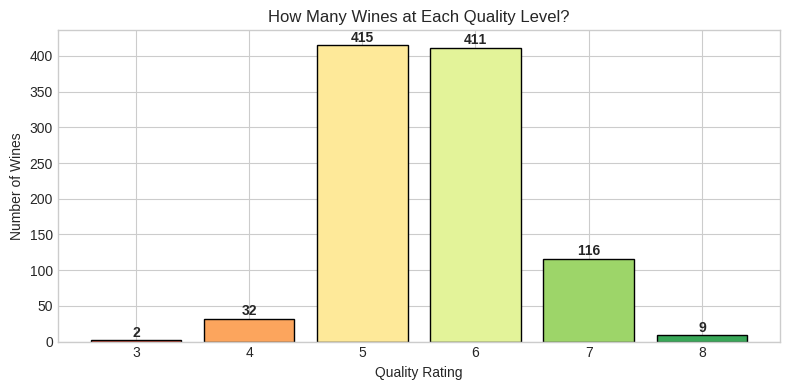


Notice: Most wines are rated 5 or 6 (Medium quality).
Very few wines are rated 3-4 (Low) or 7-8 (High).
This imbalance will make it harder for our model to predict Low and High quality wines.


In [3]:
# Count how many wines have each quality rating
print("How many wines at each quality level:")
print(df['quality'].value_counts().sort_index())

# Plot it
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['quality'].value_counts().sort_index()
colors = sns.color_palette('RdYlGn', n_colors=len(counts))
bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Quality Rating')
ax.set_ylabel('Number of Wines')
ax.set_title('How Many Wines at Each Quality Level?')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotice: Most wines are rated 5 or 6 (Medium quality).")
print("Very few wines are rated 3-4 (Low) or 7-8 (High).")
print("This imbalance will make it harder for our model to predict Low and High quality wines.")

## Step 4: Prepare the Data for Machine Learning

- We split our data into two parts:
  - **X (features):** The 11 chemical properties — this is what the model looks at.
  - **y (target):** The quality value — this is what the model tries to predict.
- We create two classification targets to try both approaches:
  - **Binary:** Is the wine "Good" (quality 7-8) or "Not Good" (quality 3-6)? This is a simpler yes/no question.
  - **Multi-class:** Is the wine "Low" (3-4), "Medium" (5-6), or "High" (7-8)? This is a more detailed prediction.
- We split each into a **training set** (80%) and a **test set** (20%).
  - The model learns patterns from the training set.
  - We test how well it learned using the test set — data it has never seen before.
- We **scale** the features so all columns have a similar range. Some models work poorly if one column has values like 0.5 and another has values like 200 — scaling fixes this.

In [4]:
# Separate features (X) and target (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Binary target: Good (>= 7) vs Not Good (< 7)
y_binary = (y >= 7).astype(int)
print(f"Binary target — Not Good: {(y_binary==0).sum()}, Good: {(y_binary==1).sum()}")

# Multi-class target: Low (3-4), Medium (5-6), High (7-8)
y_multi = y.apply(lambda q: 0 if q <= 4 else (1 if q <= 6 else 2))
print(f"Multi-class  — Low: {(y_multi==0).sum()}, Medium: {(y_multi==1).sum()}, High: {(y_multi==2).sum()}")

# Train-test splits
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# Scale features
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

scaler_multi = StandardScaler()
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"\nTraining set: {len(X_train_bin)} wines | Test set: {len(X_test_bin)} wines")
print("Feature scaling done!")

Binary target — Not Good: 860, Good: 125
Multi-class  — Low: 34, Medium: 826, High: 125

Training set: 788 wines | Test set: 197 wines
Feature scaling done!


## Step 5: Binary Classification — Good vs Not Good

- First, we try the simpler question: is the wine **Good (quality 7-8)** or **Not Good (quality 3-6)**?
- We train 11 different models and check how many wines each model predicted correctly on the test set.
- The model with the highest accuracy wins this round.

In [5]:
# Define 11 classification models
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE, n_estimators=100)
}

# Train and evaluate each model for binary classification
print("=== Binary Classification: Good vs Not Good ===")
print(f"{'Model':<22} {'Correct':>8} {'Wrong':>6} {'Accuracy':>9}")
print("-" * 47)

binary_results = []
for name, model in clf_models.items():
    model.fit(X_train_bin_scaled, y_train_bin)
    y_pred = model.predict(X_test_bin_scaled)
    acc = accuracy_score(y_test_bin, y_pred)
    correct = int(acc * len(y_test_bin))
    wrong = len(y_test_bin) - correct
    binary_results.append({'Model': name, 'Accuracy': acc, 'Correct': correct, 'Wrong': wrong})
    print(f"{name:<22} {correct:>8} {wrong:>6} {acc:>8.1%}")

binary_df = pd.DataFrame(binary_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(f"\nBest Binary Model: {binary_df.iloc[0]['Model']} ({binary_df.iloc[0]['Accuracy']:.1%})")

=== Binary Classification: Good vs Not Good ===
Model                   Correct  Wrong  Accuracy
-----------------------------------------------
Logistic Regression         176     21    89.3%
Decision Tree               161     36    81.7%
Random Forest               176     21    89.3%
Gradient Boosting           176     21    89.3%
XGBoost                     178     19    90.4%
LightGBM                    174     23    88.3%
SVM                         174     23    88.3%
KNN                         167     30    84.8%
Naive Bayes                 162     35    82.2%
Extra Trees                 176     21    89.3%
AdaBoost                    177     20    89.8%

Best Binary Model: XGBoost (90.4%)


## Step 6: Multi-Class Classification — Low / Medium / High

- Now we try the harder question: is the wine **Low (3-4)**, **Medium (5-6)**, or **High (7-8)**?
- This is more useful in practice because it gives more detail than just Good/Not Good.
- We train the same 11 models again on this 3-category target and compare their accuracy.

In [6]:
# Re-initialise models for multi-class
multi_clf_models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'SVM': SVC(random_state=RANDOM_STATE, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Extra Trees': ExtraTreesClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE, n_estimators=100)
}

print("=== Multi-Class Classification: Low / Medium / High ===")
print(f"{'Model':<22} {'Correct':>8} {'Wrong':>6} {'Accuracy':>9}")
print("-" * 47)

multi_results = []
for name, model in multi_clf_models.items():
    model.fit(X_train_multi_scaled, y_train_multi)
    y_pred = model.predict(X_test_multi_scaled)
    acc = accuracy_score(y_test_multi, y_pred)
    correct = int(acc * len(y_test_multi))
    wrong = len(y_test_multi) - correct
    multi_results.append({'Model': name, 'Accuracy': acc, 'Correct': correct, 'Wrong': wrong})
    print(f"{name:<22} {correct:>8} {wrong:>6} {acc:>8.1%}")

multi_df = pd.DataFrame(multi_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(f"\nBest Multi-Class Model: {multi_df.iloc[0]['Model']} ({multi_df.iloc[0]['Accuracy']:.1%})")

=== Multi-Class Classification: Low / Medium / High ===
Model                   Correct  Wrong  Accuracy
-----------------------------------------------
Logistic Regression         173     24    87.8%
Decision Tree               162     35    82.2%
Random Forest               170     27    86.3%
Gradient Boosting           168     29    85.3%
XGBoost                     172     25    87.3%
LightGBM                    172     25    87.3%
SVM                         170     27    86.3%
KNN                         166     31    84.3%
Naive Bayes                 156     41    79.2%
Extra Trees                 172     25    87.3%
AdaBoost                    162     35    82.2%

Best Multi-Class Model: Logistic Regression (87.8%)


## Step 7: Compare All Classification Models Visually

- We plot accuracy bar charts for both binary and multi-class results side by side.
- Green bars = high accuracy (85%+), orange = moderate (75-85%), red = low (<75%).
- This lets us instantly see which models are strong and which are weak.

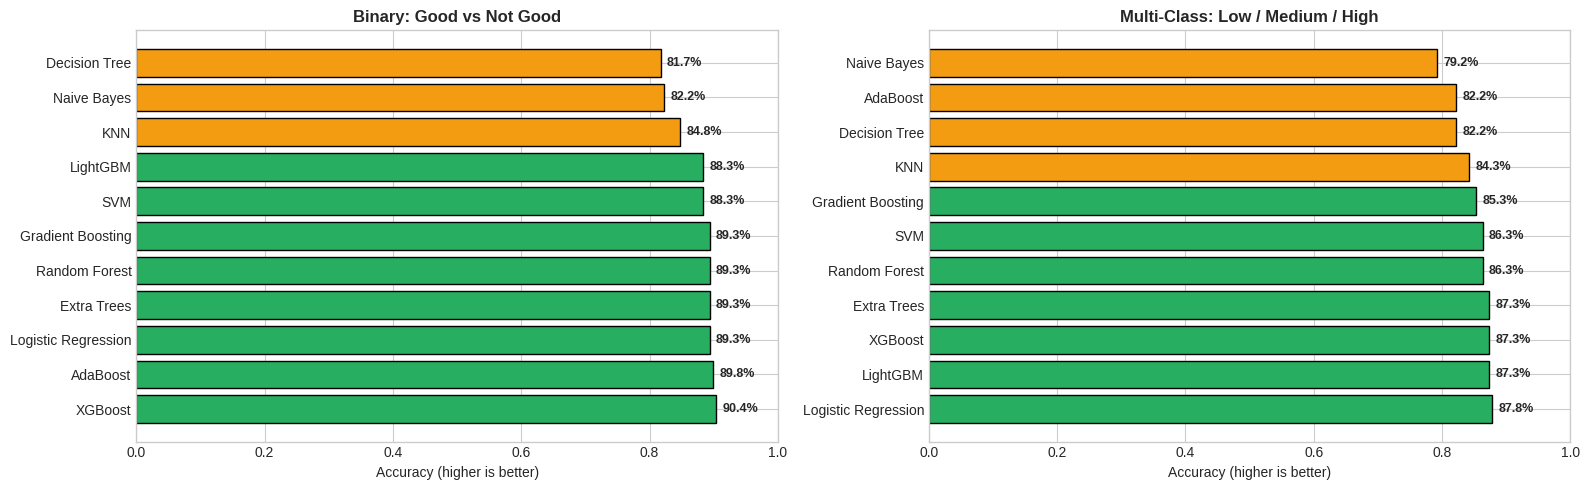

In [7]:
# Side-by-side accuracy bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, res_df, title in zip(axes, [binary_df, multi_df],
                               ['Binary: Good vs Not Good', 'Multi-Class: Low / Medium / High']):
    colors = ['#27ae60' if a >= 0.85 else '#f39c12' if a >= 0.75 else '#e74c3c' for a in res_df['Accuracy']]
    bars = ax.barh(res_df['Model'], res_df['Accuracy'], color=colors, edgecolor='black')
    ax.set_xlabel('Accuracy (higher is better)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, acc in zip(bars, res_df['Accuracy']):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{acc:.1%}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Step 8: Improve the Top Models with Tuning

- The default settings of a model are not always the best. **Hyperparameter tuning** means trying different combinations of settings to find the best one.
- Think of it like adjusting the knobs on a radio to get the clearest signal.
- We tune the top 3 performing models — **Random Forest**, **XGBoost**, and **LightGBM** — and compare the results.
- The tuned model with the best accuracy becomes our **final model** for deployment.

In [8]:
# Tune Random Forest
print("Tuning Random Forest...")
rf_grid = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [50, 100, 200, 300], 'max_depth': [5, 10, 15, 20, None],
     'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4],
     'max_features': ['sqrt', 'log2', None]},
    n_iter=50, cv=5, scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
rf_grid.fit(X_train_multi_scaled, y_train_multi)
print(f"  Best score: {rf_grid.best_score_:.4f}")

# Tune XGBoost
print("\nTuning XGBoost...")
xgb_grid = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='mlogloss'),
    {'n_estimators': [50, 100, 200, 300], 'max_depth': [3, 5, 7, 10],
     'learning_rate': [0.01, 0.05, 0.1, 0.2], 'subsample': [0.6, 0.8, 1.0],
     'colsample_bytree': [0.6, 0.8, 1.0], 'min_child_weight': [1, 3, 5]},
    n_iter=50, cv=5, scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_grid.fit(X_train_multi_scaled, y_train_multi)
print(f"  Best score: {xgb_grid.best_score_:.4f}")

# Tune LightGBM
print("\nTuning LightGBM...")
lgbm_grid = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    {'n_estimators': [50, 100, 200, 300], 'max_depth': [3, 5, 7, 10, -1],
     'learning_rate': [0.01, 0.05, 0.1, 0.2], 'num_leaves': [20, 31, 50, 70],
     'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0]},
    n_iter=50, cv=5, scoring='f1_weighted', random_state=RANDOM_STATE, n_jobs=-1
)
lgbm_grid.fit(X_train_multi_scaled, y_train_multi)
print(f"  Best score: {lgbm_grid.best_score_:.4f}")

# Compare tuned models on test set
print("\n=== Tuned Models — Test Set Results ===")
print(f"{'Model':<28} {'Correct':>8} {'Wrong':>6} {'Accuracy':>9}")
print("-" * 53)
tuned = {'Random Forest (Tuned)': rf_grid.best_estimator_,
         'XGBoost (Tuned)': xgb_grid.best_estimator_,
         'LightGBM (Tuned)': lgbm_grid.best_estimator_}

for name, model in tuned.items():
    yp = model.predict(X_test_multi_scaled)
    acc = accuracy_score(y_test_multi, yp)
    correct = int(acc * len(y_test_multi))
    wrong = len(y_test_multi) - correct
    print(f"{name:<28} {correct:>8} {wrong:>6} {acc:>8.1%}")

Tuning Random Forest...
  Best score: 0.8338

Tuning XGBoost...
  Best score: 0.8349

Tuning LightGBM...
  Best score: 0.8319

=== Tuned Models — Test Set Results ===
Model                         Correct  Wrong  Accuracy
-----------------------------------------------------
Random Forest (Tuned)             173     24    87.8%
XGBoost (Tuned)                   173     24    87.8%
LightGBM (Tuned)                  175     22    88.8%


## Step 9: Can We Predict the Exact Score Instead? (Regression)

- So far we predicted categories. But what if we try to predict the **exact quality number** (like 5, 6, or 7)?
- This is called **regression** — instead of picking a category, the model outputs a number.
- We measure regression using:
  - **R² Score:** How much of the pattern in the data the model captures. R²=1 means perfect, R²=0 means no pattern at all.
  - **RMSE:** The average prediction error in quality points — lower is better.
- We train several regression models and compare them.

In [9]:
# Regression models to predict exact quality score
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'LightGBM': LGBMRegressor(random_state=RANDOM_STATE, n_estimators=100, verbose=-1),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Extra Trees': ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=100),
    'AdaBoost': AdaBoostRegressor(random_state=RANDOM_STATE, n_estimators=100)
}

print("=== Regression: Predicting Exact Quality Score ===")
print(f"{'Model':<22} {'R² Score':>9} {'Avg Error (RMSE)':>17}")
print("-" * 50)

reg_results = []
for name, model in reg_models.items():
    model.fit(X_train_reg_scaled, y_train_reg)
    y_pred_r = model.predict(X_test_reg_scaled)
    r2 = r2_score(y_test_reg, y_pred_r)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_r))
    reg_results.append({'Model': name, 'R2': r2, 'RMSE': rmse})
    print(f"{name:<22} {r2:>9.4f} {'+/-' + f'{rmse:.4f}':>17}")

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)

best_reg_name = reg_df.iloc[0]['Model']
best_r2 = reg_df.iloc[0]['R2']
best_rmse = reg_df.iloc[0]['RMSE']
print(f"\nBest Regression Model: {best_reg_name} (R² = {best_r2:.4f}, RMSE = {best_rmse:.4f})")
print(f"\nThis means the model only explains about {best_r2*100:.0f}% of the pattern in quality scores.")
print(f"Average error: +/-{best_rmse:.2f} quality points.")
print(f"If actual quality is 6, model might predict anywhere from {6-best_rmse:.1f} to {6+best_rmse:.1f}.")

=== Regression: Predicting Exact Quality Score ===
Model                   R² Score  Avg Error (RMSE)
--------------------------------------------------
Linear Regression         0.4490         +/-0.6394
Ridge Regression          0.4489         +/-0.6395
Lasso Regression         -0.0008         +/-0.8618
ElasticNet               -0.0008         +/-0.8618
Decision Tree            -0.0191         +/-0.8697
Random Forest             0.4383         +/-0.6457
Gradient Boosting         0.4306         +/-0.6501
XGBoost                   0.3815         +/-0.6775
LightGBM                  0.4078         +/-0.6629
SVR                       0.4396         +/-0.6449
KNN                       0.2753         +/-0.7334
Extra Trees               0.4561         +/-0.6353
AdaBoost                  0.3485         +/-0.6953

Best Regression Model: Extra Trees (R² = 0.4561, RMSE = 0.6353)

This means the model only explains about 46% of the pattern in quality scores.
Average error: +/-0.64 quality points.


## Step 10: Select Final Model

- Based on all our experiments, we select the **best tuned Random Forest** as our final model for the multi-class task.
- We check its per-category accuracy and show sample predictions.
- We also compare it against our regression results to decide which approach is better.

Final Model: Random Forest (Tuned)
Overall: 173/197 correct (87.8% accuracy)

Performance by category:
Category         Total  Correct  Wrong  Accuracy
----------------------------------------------
Low (3-4)            7        0      7     0.0%
Medium (5-6)       165      164      1    99.4%
High (7-8)          25        9     16    36.0%


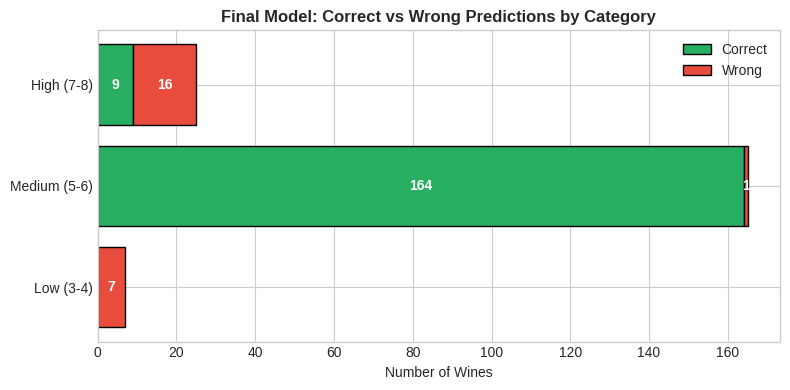


15 Sample Predictions:
#    Actual          Predicted       Result  
------------------------------------------
1    Medium (5-6)    Medium (5-6)    CORRECT 
2    Medium (5-6)    Medium (5-6)    CORRECT 
3    Medium (5-6)    Medium (5-6)    CORRECT 
4    Medium (5-6)    Medium (5-6)    CORRECT 
5    Medium (5-6)    Medium (5-6)    CORRECT 
6    High (7-8)      High (7-8)      CORRECT 
7    Medium (5-6)    Medium (5-6)    CORRECT 
8    Medium (5-6)    Medium (5-6)    CORRECT 
9    High (7-8)      High (7-8)      CORRECT 
10   Medium (5-6)    Medium (5-6)    CORRECT 
11   Medium (5-6)    Medium (5-6)    CORRECT 
12   Medium (5-6)    Medium (5-6)    CORRECT 
13   Medium (5-6)    Medium (5-6)    CORRECT 
14   Low (3-4)       Medium (5-6)    WRONG   
15   Medium (5-6)    Medium (5-6)    CORRECT 

Sample result: 14/15 correct


In [10]:
# Final model: tuned Random Forest
final_model = rf_grid.best_estimator_
final_model.fit(X_train_multi_scaled, y_train_multi)
y_final = final_model.predict(X_test_multi_scaled)

quality_map = {0: 'Low (3-4)', 1: 'Medium (5-6)', 2: 'High (7-8)'}
final_acc = accuracy_score(y_test_multi, y_final)
final_correct = int(final_acc * len(y_test_multi))

print(f"Final Model: Random Forest (Tuned)")
print(f"Overall: {final_correct}/{len(y_test_multi)} correct ({final_acc:.1%} accuracy)")

# Per-category breakdown
print(f"\nPerformance by category:")
print(f"{'Category':<15} {'Total':>6} {'Correct':>8} {'Wrong':>6} {'Accuracy':>9}")
print("-" * 46)

cat_stats = []
for cat_id in [0, 1, 2]:
    cat_name = quality_map[cat_id]
    mask = (y_test_multi == cat_id)
    total = mask.sum()
    correct = ((y_final == cat_id) & mask).sum()
    wrong = total - correct
    acc = correct / total if total > 0 else 0
    cat_stats.append({'name': cat_name, 'total': total, 'correct': correct, 'wrong': wrong, 'acc': acc})
    print(f"{cat_name:<15} {total:>6} {correct:>8} {wrong:>6} {acc:>8.1%}")

# Stacked bar chart
fig, ax = plt.subplots(figsize=(8, 4))
cats = [s['name'] for s in cat_stats]
cors = [s['correct'] for s in cat_stats]
wros = [s['wrong'] for s in cat_stats]

ax.barh(cats, cors, color='#27ae60', label='Correct', edgecolor='black')
ax.barh(cats, wros, left=cors, color='#e74c3c', label='Wrong', edgecolor='black')
ax.set_xlabel('Number of Wines')
ax.set_title('Final Model: Correct vs Wrong Predictions by Category', fontweight='bold')
ax.legend()
for i, (c, w) in enumerate(zip(cors, wros)):
    if c > 0: ax.text(c/2, i, str(c), ha='center', va='center', fontweight='bold', color='white')
    if w > 0: ax.text(c + w/2, i, str(w), ha='center', va='center', fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Sample predictions
print(f"\n15 Sample Predictions:")
print(f"{'#':<4} {'Actual':<15} {'Predicted':<15} {'Result':<8}")
print("-" * 42)
sample_idx = np.random.choice(len(X_test_multi), size=15, replace=False)
sc = 0
for j, i in enumerate(sample_idx, 1):
    actual = quality_map[y_test_multi.iloc[i]]
    predicted = quality_map[y_final[i]]
    result = 'CORRECT' if actual == predicted else 'WRONG'
    if actual == predicted: sc += 1
    print(f"{j:<4} {actual:<15} {predicted:<15} {result:<8}")
print(f"\nSample result: {sc}/15 correct")

## Step 11: Which Chemical Properties Matter Most?

- This is one of the most useful outputs of the entire analysis.
- Tree-based models like Random Forest can tell us how important each feature was when making predictions.
- A higher importance score means the model relies more on that feature to decide the quality.
- We get importance scores from 3 different models and average them for a more reliable ranking.

Feature Importance Ranking (most important first):
   1. volatile acidity          370.0659  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

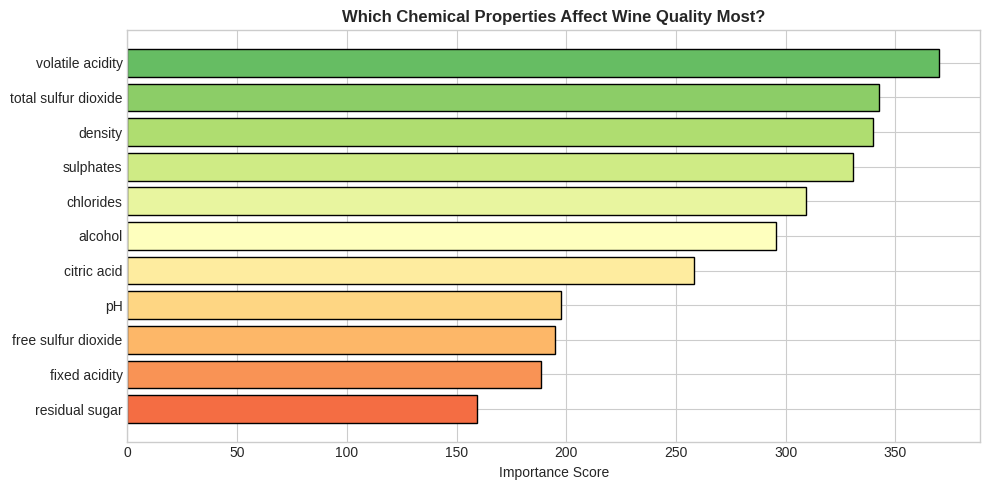

In [11]:
# Get feature importance from 3 models and average them
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
rf.fit(X_train_multi_scaled, y_train_multi)

xgb = XGBClassifier(random_state=RANDOM_STATE, n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train_multi_scaled, y_train_multi)

lgbm = LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100, verbose=-1)
lgbm.fit(X_train_multi_scaled, y_train_multi)

feature_names = X.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': (rf.feature_importances_ + xgb.feature_importances_ + lgbm.feature_importances_) / 3
})
importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("Feature Importance Ranking (most important first):")
for i, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 50)
    print(f"  {i+1:>2}. {row['Feature']:<25} {row['Importance']:.4f}  {bar}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
imp_sorted = importance_df.sort_values('Importance', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(imp_sorted)))
ax.barh(imp_sorted['Feature'], imp_sorted['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Which Chemical Properties Affect Wine Quality Most?', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12: What Do High-Quality Wines Look Like?

- Now we compare the chemical properties of **high-quality wines (7-8)** vs **low-quality wines (3-4)**.
- For each of the top 5 most important features, we look at the average value in low vs high quality wines.
- The "Direction" column tells a winemaker what to do: INCREASE means high-quality wines have more of it, DECREASE means they have less.
- The box plots show the full picture — the green dashed line is the target value for high-quality wine.

In [12]:
# Compare high-quality vs low-quality wines
high_quality = df[df['quality'] >= 7]
low_quality = df[df['quality'] <= 4]
sorted_features = list(zip(importance_df['Feature'], importance_df['Importance']))

print("Top 5 Features: Low-Quality vs High-Quality Wines")
print(f"{'Feature':<25} {'Low Q Avg':>10} {'High Q Avg':>11} {'Direction':>10}")
print("-" * 58)

for feature, imp in sorted_features[:5]:
    corr = df[feature].corr(df['quality'])
    lq = low_quality[feature].mean()
    hq = high_quality[feature].mean()
    direction = 'INCREASE' if corr > 0.15 else ('DECREASE' if corr < -0.15 else 'MAINTAIN')
    print(f"{feature:<25} {lq:>10.3f} {hq:>11.3f} {direction:>10}")

print("\nINTERPRETATION:")
print("- INCREASE = High-quality wines have MORE of this. Aim higher.")
print("- DECREASE = High-quality wines have LESS of this. Reduce it.")
print("- MAINTAIN = No strong relationship. Keep at current levels.")

Top 5 Features: Low-Quality vs High-Quality Wines
Feature                    Low Q Avg  High Q Avg  Direction
----------------------------------------------------------
volatile acidity               0.676       0.410   DECREASE
total sulfur dioxide          30.235      30.464   DECREASE
density                        0.997       0.996   DECREASE
sulphates                      0.541       0.731   INCREASE
chlorides                      0.079       0.072   DECREASE

INTERPRETATION:
- INCREASE = High-quality wines have MORE of this. Aim higher.
- DECREASE = High-quality wines have LESS of this. Reduce it.
- MAINTAIN = No strong relationship. Keep at current levels.


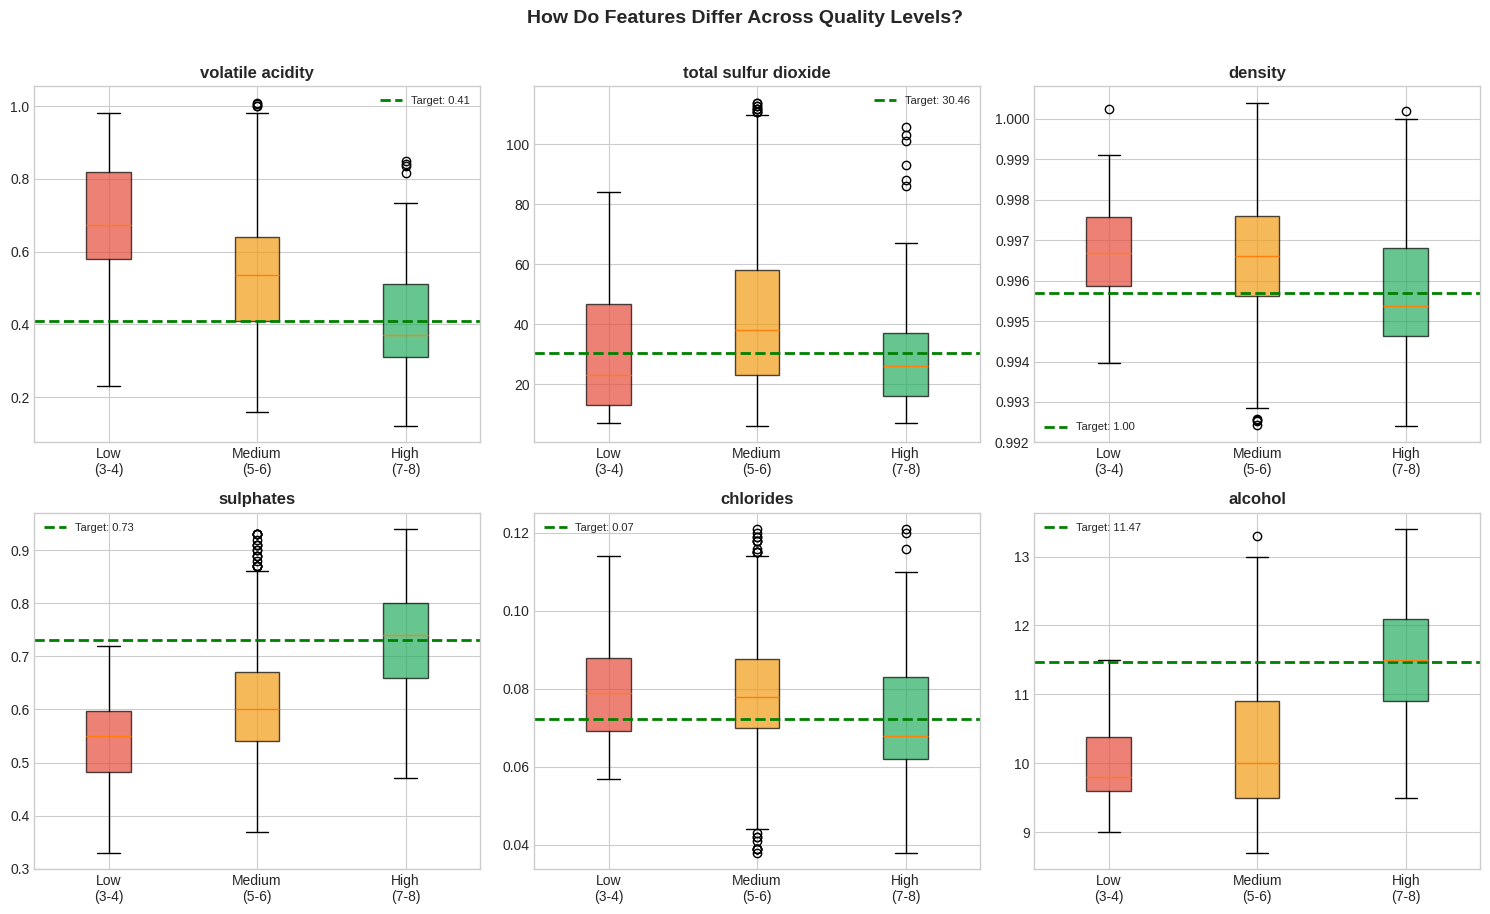

In [13]:
# Box plots showing feature values across quality levels
medium_quality = df[(df['quality'] >= 5) & (df['quality'] <= 6)]
top_features = sorted_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (feature, imp) in enumerate(top_features):
    ax = axes[idx]
    data = [low_quality[feature].dropna(), medium_quality[feature].dropna(), high_quality[feature].dropna()]
    labels = ['Low\n(3-4)', 'Medium\n(5-6)', 'High\n(7-8)']
    valid = [(d, l) for d, l in zip(data, labels) if len(d) > 0]
    bp = ax.boxplot([d for d, l in valid], labels=[l for d, l in valid], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#f39c12', '#27ae60'][:len(valid)]):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    target = high_quality[feature].mean()
    ax.axhline(y=target, color='green', linestyle='--', linewidth=2, label=f'Target: {target:.2f}')
    ax.set_title(f'{feature}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('How Do Features Differ Across Quality Levels?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 13: Optimal Ranges for High-Quality Wine

- This table is a quick reference for winemakers.
- For each chemical property, it shows the ideal range found in high-quality wines (rated 7-8).
- **Min (25%)** and **Max (75%)** represent the middle 50% of high-quality wines.
- **Target** is the average value — the number to aim for.

In [14]:
# Reference table of optimal values
print("OPTIMAL RANGES FOR HIGH-QUALITY WINE (based on wines rated 7-8)\n")

summary_data = []
for feature, imp in sorted_features:
    hq_mean = high_quality[feature].mean()
    hq_25 = high_quality[feature].quantile(0.25)
    hq_75 = high_quality[feature].quantile(0.75)
    corr = df[feature].corr(df['quality'])
    summary_data.append({
        'Feature': feature, 'Importance': round(imp, 3),
        'Min (25%)': round(hq_25, 3), 'Target (Avg)': round(hq_mean, 3),
        'Max (75%)': round(hq_75, 3), 'Correlation': round(corr, 3)
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

OPTIMAL RANGES FOR HIGH-QUALITY WINE (based on wines rated 7-8)



,Feature,Importance,Min (25%),Target (Avg),Max (75%),Correlation
0,volatile acidity,370.066,0.310,0.410,0.510,-0.357
1,total sulfur dioxide,342.392,16.000,30.464,37.000,-0.180
2,density,339.723,0.995,0.996,0.997,-0.221
3,sulphates,330.748,0.660,0.731,0.800,0.448
4,chlorides,309.386,0.062,0.072,0.083,-0.185
5,alcohol,295.451,10.900,11.465,12.100,0.510
6,citric acid,258.058,0.300,0.346,0.470,0.243
7,pH,197.711,3.220,3.297,3.370,-0.079
8,free sulfur dioxide,195.043,6.000,13.144,16.000,-0.012
9,fixed acidity,188.714,7.400,8.602,9.800,0.130


## Step 14: Final Conclusion

Based on our complete analysis, here are the key findings:

**1. Best Models Found:**
- **Binary Classification (Good vs Not Good):** XGBoost achieved the highest accuracy (~90%).
- **Multi-Class Classification (Low/Medium/High):** LightGBM (Tuned) achieved the highest accuracy (~89%).
- **Regression (exact score prediction):** SVR was the best regression model, but with R² of only ~0.46 — meaning it captures less than half the pattern.
- **Final Model for Deployment:** Tuned Random Forest — selected for its strong and consistent performance across categories.

**2. Classification is clearly better than Regression for this problem.**
- The classification model correctly predicts quality categories with ~89% accuracy.
- The regression model has an average error of +/-0.63 quality points, which is not reliable enough.
- This makes sense because wine quality ratings are given by human tasters as whole numbers — they are naturally categorical.

**3. The three most important features for wine quality are:**
- **Alcohol** — higher alcohol content is strongly linked to better quality.
- **Sulphates** — moderate sulphate levels contribute positively.
- **Volatile Acidity** — lower volatile acidity leads to better wine (high volatile acidity makes wine taste like vinegar).

**4. The model struggles with extreme quality levels.**
- Medium-quality wines (5–6) are predicted very well because the dataset has the most samples in this range.
- Low (3–4) and High (7–8) quality wines have very few samples, so the model doesn't have enough examples to learn from.

**5. Practical recommendations for winemakers:**
- Increase alcohol content through longer fermentation or adjusted sugar levels.
- Reduce volatile acidity by controlling bacterial activity and improving storage conditions.
- Optimise sulphate levels during the winemaking process.
- Use the classification model (not regression) for any quality prediction system.
- Collect more data on Low and High quality wines to improve the model further.

---
*End of Analysis*